# Predicting loan amount for accepted LendingClub applications

**Data Visualization project, Part A, steps 1 to 5:** dataset, load, pre-cleaning insights, cleaning, and before/after visuals.

This notebook goes from the raw Kaggle file to a cleaned table. Steps 6 to 9 (ML direction, feature selection, decision table, dashboard) start from that table.

**To run it**

1. Download `accepted_2007_to_2018Q4.csv.gz` from <https://www.kaggle.com/datasets/wordsforthewise/lending-club> (Kaggle login needed) and put it in `data/raw/`.
2. Install the packages in `requirements.txt`.
3. Run all cells from top to bottom. The load alone takes one to two minutes, and the machine needs roughly 8 GB of free memory.

**What it writes**

| File | What it is | In git? |
|---|---|---|
| `data/processed/loans_clean.parquet` | The cleaned table, one row per loan | No (too large; re-create it by running this notebook) |
| `outputs/column_tags.csv` | Every cleaned column with its role (target, leakage, LC pricing, post-issue, application-time) | Yes |
| `outputs/figures/*.png` | The charts below, for slides and the report | Yes |

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "accepted_2007_to_2018Q4.csv.gz"
CLEAN_PATH = ROOT / "data" / "processed" / "loans_clean.parquet"
TAGS_PATH = ROOT / "outputs" / "column_tags.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

TARGET = "loan_amnt"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

# One look for every chart: blue for the main series, orange for the comparison series.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUES = LinearSegmentedColormap.from_list("blues", [SURFACE, "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "legend.frameon": False,
})


def save(fig, name):
    """Save a chart to outputs/figures for slides and the report."""
    fig.savefig(FIG_DIR / name, dpi=120, bbox_inches="tight")


print("pandas", pd.__version__, "| data file found:", DATA_PATH.exists())

pandas 3.0.3 | data file found: True


## 1. Dataset, motivation and complexity

Every number in this section is measured further down; the section that produces it is named in brackets.

### 1.1 The question and who cares

**Main question: what determines how much an accepted LendingClub borrower takes out, and can we predict `loan_amnt`?**

Sub-questions the dashboard will answer:

- Which borrower traits go with larger loans (income, existing debt, credit history, home ownership)?
- How did loan size change between 2007 and 2018?
- How does loan size differ by purpose and by state?

Who cares:

- **A lender** wants to anticipate how much a new applicant will ask for, to plan funding and to make pre-qualified offers.
- **A borrower** wants to know what people in a similar position borrow.

### 1.2 Source and provenance

- LendingClub was a US peer-to-peer lender: people applied for unsecured personal loans and investors funded them. It published loan-level data for those investors. The Kaggle dataset `wordsforthewise/lending-club` is an archived copy of those files.
- LendingClub closed its investor (Notes) platform on 31 December 2020, so the series is complete and no longer updated at the source ([Finextra](https://www.finextra.com/pressarticle/84439/lendingclub-sunsets-notes-platform), [Banking Dive](https://bankingdive.com/news/lendingclub-peer-to-peer-loans/586841)).
- Coverage: loans issued from June 2007 to December 2018 [2.4]. One row is one issued loan.
- The file is a snapshot taken around March 2019: the most common last-payment month is Mar-2019 [2.2]. Loans issued late in the period were still being repaid at that point.

### 1.3 Size and features

- 393 MB compressed, 2,260,701 rows and 151 columns, 3.3 GB once loaded [2.1].
- 113 columns are numeric and 38 are text [2.1].
- 33 rows are not loans but summary lines left over from the quarterly files, so the file holds 2,260,668 loans [2.3].
- The 151 columns fall into seven kinds of information [2.5]:

| Group | Columns | What it holds |
|---|---|---|
| Credit bureau file | 69 | The borrower's credit report at application: accounts, balances, limits, delinquencies, FICO range |
| Loan terms and listing | 19 | Amount, term, rate, grade, purpose, issue date |
| Post-issue performance | 17 | What happened after the loan was issued: status, payments, recoveries |
| Joint / second applicant | 16 | Income, DTI and credit details of a co-borrower |
| Hardship plan | 15 | Details of payment-relief plans |
| Borrower profile | 8 | Job title, employment length, income, home ownership, state, DTI |
| Debt settlement | 7 | Details of settled debts |

### 1.4 Why this dataset

- **Real and large.** 2.26 million real loans, not a synthetic or toy file. The pandas load takes over a minute on a laptop, so GPU acceleration has something to speed up.
- **Mixed data types.** Numbers, categories, dates stored as text, free text and geography in one table, which supports varied chart types and a state map in Tableau.
- **Twelve years of history.** Yearly volume grows from 603 loans in 2007 to 495,242 in 2018 [2.4], so there is a time story.
- **Untidy in ways that need real cleaning.** See 1.6.
- **Why the accepted file only.** The same Kaggle dataset has a rejected-applications file, but it has only 9 columns (amount requested, application date, loan title, risk score, DTI, zip code, state, employment length, policy code). It has no income and no credit history, so it cannot support a question about what drives loan size. (Checked by reading the header of `rejected_2007_to_2018Q4.csv.gz`.)

### 1.5 Why loan amount as the target

- `loan_amnt` is a dollar amount, so the Part B task is **regression**. Most projects on this dataset predict default instead; loan size is a less worn question.
- What it records: the amount the borrower applied for, lowered if LendingClub's credit department reduced it (LendingClub data dictionary). So the target mixes what the borrower wanted with what the lender allowed, and we say so openly.
- It is complete: every one of the 2,260,668 loans has a value, from \$500 to \$40,000 [2.2].

### 1.6 Data complexity

- **Volume and width:** 2.26M rows by 151 columns, 3.3 GB in memory [2.1].
- **Missing values with structure, not random gaps:** 58 of 151 columns are more than 30% empty, and nothing sits between 13% and 38% [3.2]. Whole blocks of columns only exist from 2012, from December 2015 or from 2017, because LendingClub added fields over time [3.3]. Joint-applicant, hardship and settlement columns apply to under 6% of loans.
- **Numbers and dates stored as text:** `term` is `" 36 months"`, `emp_length` is `"10+ years"`, dates are `"Dec-2015"` [3.6].
- **High-cardinality free text:** `emp_title` has 512,694 distinct values [2.2].
- **Summary rows mixed into the data:** 33 of them [2.3].
- **Extreme values:** `annual_inc` reaches \$110 million and `dti` reaches 999 [3.4]. The broken `dti` and zero-income values all belong to joint applications, where the individual field is not the one LendingClub used.
- **Empty, constant and redundant columns:** `member_id` is empty, `policy_code` is always 1, and `fico_range_high` is always `fico_range_low` plus 4 or 5 [3.7].

### 1.7 Problem complexity

- **Heaped target:** borrowers pick round numbers. 70% of loans are an exact multiple of \$1,000 and 34% a multiple of \$5,000 [3.5].
- **Bounded target, and the bound moved:** the maximum was \$25,000 until 2010, \$35,000 from 2011 and \$40,000 from March 2016 [3.5]. Reported at the time by [PR Newswire](https://www.prnewswire.com/news-releases/lending-club-increases-maximum-personal-loan-size-to-35000-116217554.html) and [deBanked](https://debanked.com/2016/03/lending-club-loan-size-cap-raised-to-40000-should-investors-be-worried/).
- **Leakage in three forms** [3.7]:
  - restatements of the target: `funded_amnt` equals `loan_amnt` in 99.9% of loans, and `installment` is computed from it;
  - post-issue outcomes: payments, recoveries, loan status, which do not exist when the amount is decided;
  - lender pricing: grade and interest rate, which LendingClub sets knowing the amount.
- **Selection:** the file holds accepted loans only, so conclusions do not extend to everyone who applied.
- **Drift:** twelve years in which volume, the borrower mix and the platform's rules all changed [2.4].
- **Part of the amount is personal choice.** Two people with the same profile can want different amounts, so we should expect moderate, not high, accuracy from application-time features. Saying this up front sets a fair bar for Part B.

### 1.8 Complexity scorecard

The scorecard table is built from the data at the end of section 3 [3.8], so its numbers cannot drift from the notebook.

## 2. Load the dataset

### 2.1 Full load, timed

The whole file is read with pandas. `low_memory=False` makes pandas decide each column's type from the full column instead of chunk by chunk, which avoids mixed-type warnings.

In [2]:
t0 = time.perf_counter()
df = pd.read_csv(DATA_PATH, low_memory=False)
load_seconds = time.perf_counter() - t0

n_rows_raw, n_cols_raw = df.shape
mem_gb_raw = df.memory_usage(deep=True).sum() / 1e9
dtypes_raw = df.dtypes.astype(str).value_counts()

print(f"File on disk : {DATA_PATH.stat().st_size / 1e6:,.0f} MB (gzip)")
print(f"Load time    : {load_seconds:,.0f} s with pandas {pd.__version__} on CPU")
print(f"Shape        : {n_rows_raw:,} rows x {n_cols_raw} columns")
print(f"In memory    : {mem_gb_raw:.2f} GB")
print(f"Column types : {dtypes_raw.to_dict()}")

File on disk : 393 MB (gzip)
Load time    : 64 s with pandas 3.0.3 on CPU
Shape        : 2,260,701 rows x 151 columns
In memory    : 3.29 GB
Column types : {'float64': 113, 'str': 38}


### 2.2 First inspection

Nothing is assumed about the columns. The next four outputs are the basis for everything said about the data later: non-null counts and types for all 151 columns, the first rows, and summary statistics for the numeric and the text columns.

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  str    
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  str    
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  str    
 9    sub_grade                                   2260668 non

In [4]:
# First three rows, turned sideways so all 151 columns are visible.
df.head(3).T

,0,1,2
id,68407277,68355089,68341763
member_id,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0
funded_amnt,3600.0,24700.0,20000.0
funded_amnt_inv,3600.0,24700.0,20000.0
term,36 months,36 months,60 months
int_rate,13.99,11.99,10.78
installment,123.03,820.28,432.66
grade,C,C,B
sub_grade,C4,C1,B4


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.93,9190.25,500.00,8000.00,12900.00,20000.00,4.000000e+04
funded_amnt,2260668.0,15041.66,9188.41,500.00,8000.00,12875.00,20000.00,4.000000e+04
funded_amnt_inv,2260668.0,15023.44,9192.33,0.00,8000.00,12800.00,20000.00,4.000000e+04
int_rate,2260668.0,13.09,4.83,5.31,9.49,12.62,15.99,3.099000e+01
installment,2260668.0,445.81,267.17,4.93,251.65,377.99,593.32,1.719830e+03
annual_inc,2260664.0,77992.43,112696.20,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.82,14.18,-1.00,11.89,17.84,24.49,9.990000e+02
delinq_2yrs,2260639.0,0.31,0.87,0.00,0.00,0.00,0.00,5.800000e+01
fico_range_low,2260668.0,698.59,33.01,610.00,675.00,690.00,715.00,8.450000e+02


In [6]:
df.describe(exclude="number").T

,count,unique,top,freq
id,2260701,2260701,68407277,1
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
emp_length,2113761,11,10+ years,748005
home_ownership,2260668,6,MORTGAGE,1111450
verification_status,2260668,3,Source Verified,886231
issue_d,2260668,139,Mar-2016,61992
loan_status,2260668,9,Fully Paid,1076751


**What these outputs show**

- **Target.** `loan_amnt` runs from \$500 to \$40,000 with a median of \$12,900 and a mean of \$15,047. `funded_amnt` has almost the same statistics.
- **33 rows are not loans.** `id` is filled in all 2,260,701 rows but no other column is filled in more than 2,260,668 (checked in 2.3).
- **Empty and constant columns.** `member_id` has no values. `policy_code` is 1 everywhere. `hardship_type` has one value.
- **Columns that apply to few loans.** Joint-applicant fields have about 120,000 values, settlement fields 34,246 and hardship fields 10,917, out of 2.26 million.
- **Blocks with the same count.** Thirteen credit-bureau columns from `open_acc_6m` to `inq_last_12m` all have about 1.39 million values, which points to fields added partway through the period (tested in 3.3).
- **Text that should be numbers or dates.** `term`, `emp_length`, `issue_d`, `earliest_cr_line`.
- **Free text.** `emp_title` has 512,694 distinct values, `title` 63,154.
- **Implausible extremes.** `annual_inc` goes up to 110,000,000, `dti` from -1 to 999, `revol_util` up to 892%.
- **Snapshot date.** The most common `last_pymnt_d` is Mar-2019 and the most common `next_pymnt_d` is Apr-2019.

### 2.3 Rows that are not loans

In [7]:
not_loan = df[TARGET].isna()
loans = ~not_loan
n_summary_rows = int(not_loan.sum())

print(f"Rows without a loan amount            : {n_summary_rows}")
print(f"Filled cells in them, other than `id` : {df.loc[not_loan].drop(columns='id').notna().sum().sum()}")
print(f"Loans in the file                     : {loans.sum():,}")
df.loc[not_loan, ["id"]].head(6)

Rows without a loan amount            : 33
Filled cells in them, other than `id` : 0
Loans in the file                     : 2,260,668


,id
421095,Total amount funded in policy code 1: 6417608175
421096,Total amount funded in policy code 2: 1944088810
528961,Total amount funded in policy code 1: 1741781700
528962,Total amount funded in policy code 2: 564202131
651664,Total amount funded in policy code 1: 1791201400
651665,Total amount funded in policy code 2: 651669342


The 33 rows carry a sentence in the `id` column ("Total amount funded in policy code 1: ...") and nothing else. They are the totals lines at the end of each quarterly file that was stacked to make this one. They are removed in step 4.

### 2.4 Duplicates, date range and volume by year

In [8]:
n_duplicate_ids = int(df.loc[loans, "id"].duplicated().sum())
issue_date = pd.to_datetime(df["issue_d"], format="%b-%Y")

print(f"Duplicate loan ids : {n_duplicate_ids}")
print(f"Issue dates        : {issue_date.min():%b %Y} to {issue_date.max():%b %Y} ({issue_date.nunique()} months)")

by_year = df.groupby(issue_date.dt.year)[TARGET].agg(loans="size", median="median", mean="mean", max="max")
by_year.index = by_year.index.astype(int)
by_year.index.name = "issue year"
by_year.round(0).astype(int)

Duplicate loan ids : 0
Issue dates        : Jun 2007 to Dec 2018 (139 months)


,loans,median,mean,max
issue year,,,,
2007,603,6000,8255,25000
2008,2393,7500,8825,25000
2009,5281,8800,9833,25000
2010,12537,9300,10528,25000
2011,21721,10000,12048,35000
2012,53367,12000,13462,35000
2013,134814,13000,14707,35000
2014,235629,13000,14870,35000
2015,421095,14000,15240,35000


- No loan appears twice.
- Volume grows from 603 loans in 2007 to 495,242 in 2018. 2015 to 2018 hold 79% of all loans, so any overall average is mostly about those four years.
- The largest loan steps up from \$25,000 to \$35,000 in 2011 and to \$40,000 in 2016. That is a policy limit, looked at more closely in 3.5.

### 2.5 What the 151 columns describe

Each column is assigned to one of seven groups by name. The check at the end fails if any column is left out, named twice or misspelled, so nothing can be filed silently.

In [9]:
cols = list(df.columns)


def block(first, last):
    """Columns from `first` to `last` inclusive, in file order."""
    return cols[cols.index(first): cols.index(last) + 1]


GROUPS = {
    "Loan terms and listing": [
        "id", "member_id", "loan_amnt", "funded_amnt", "funded_amnt_inv", "term", "int_rate", "installment",
        "grade", "sub_grade", "issue_d", "url", "desc", "purpose", "title", "initial_list_status",
        "policy_code", "application_type", "disbursement_method",
    ],
    "Borrower profile": [
        "emp_title", "emp_length", "home_ownership", "annual_inc", "verification_status",
        "zip_code", "addr_state", "dti",
    ],
    "Credit bureau file": (
        block("delinq_2yrs", "total_acc")
        + ["collections_12_mths_ex_med", "mths_since_last_major_derog"]
        + block("acc_now_delinq", "total_il_high_credit_limit")
    ),
    "Post-issue performance": ["loan_status", "pymnt_plan"] + block("out_prncp", "last_fico_range_low"),
    "Joint / second applicant": (
        block("annual_inc_joint", "verification_status_joint")
        + block("revol_bal_joint", "sec_app_mths_since_last_major_derog")
    ),
    "Hardship plan": block("hardship_flag", "hardship_last_payment_amount"),
    "Debt settlement": block("debt_settlement_flag", "settlement_term"),
}

assigned = [c for members in GROUPS.values() for c in members]
unassigned = [c for c in cols if c not in assigned]
named_twice = sorted({c for c in assigned if assigned.count(c) > 1})
print(f"Columns assigned: {len(assigned)} of {len(cols)} | unassigned: {unassigned} | named twice: {named_twice}")
assert not unassigned and not named_twice and len(assigned) == len(cols)

group_of = pd.Series({c: g for g, members in GROUPS.items() for c in members}, name="group")
kind = df.dtypes.astype(str).eq("str").map({True: "text", False: "numeric"})
# Share of missing values per column, measured over the loans (the 33 summary rows are left out).
null_pct_raw = df.isna().loc[loans].mean().mul(100)

group_table = pd.crosstab(group_of, kind.reindex(group_of.index).values)
group_table.insert(0, "columns", group_table.sum(axis=1))
group_table["median % missing"] = null_pct_raw.groupby(group_of).median().round(1)
group_table = group_table.sort_values("columns", ascending=False)
group_table.index.name, group_table.columns.name = "group", None
group_table

Columns assigned: 151 of 151 | unassigned: [] | named twice: []


,columns,numeric,text,median % missing
group,,,,
Credit bureau file,69,68,1,3.1
Loan terms and listing,19,7,12,0.0
Post-issue performance,17,12,5,0.0
Joint / second applicant,16,14,2,95.2
Hardship plan,15,7,8,99.5
Borrower profile,8,2,6,0.0
Debt settlement,7,3,4,98.5


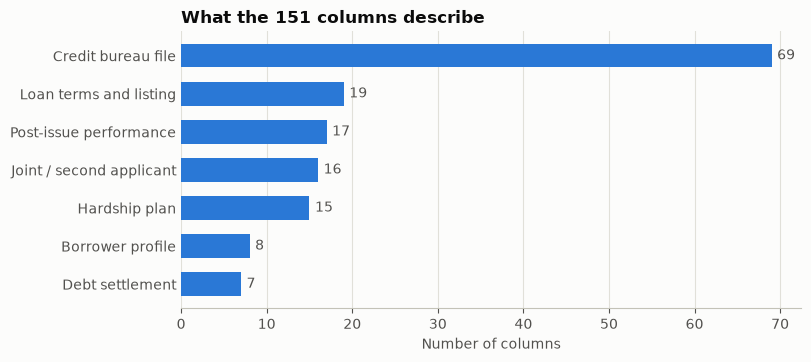

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))
plot = group_table["columns"].sort_values()
bars = ax.barh(plot.index, plot.values, color=BLUE, height=0.62)
ax.bar_label(bars, padding=4, color=INK2)
ax.set_title(f"What the {len(cols)} columns describe")
ax.set_xlabel("Number of columns")
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "01_feature_groups.png")
plt.show()

- Almost half the columns (69) are the borrower's credit report.
- Only 8 columns describe the borrower directly, and a few loan-listing columns (purpose, issue date, application type) are also known at application.
- 55 columns (post-issue, joint, hardship, settlement) either describe what happened after the loan was issued or apply to a small share of loans. The joint, hardship and settlement groups are almost entirely empty (median missing above 95%).